#Lab Session 6

We will implement a RNN from scratch using `pytorch`, based on Chapter 9 and 10 of the textbook (<a href="https://d2l.ai/chapter_recurrent-neural-networks/rnn.html">Zhang et al.</a>), and use it to implement a simple language model.

In [ ]:
import math
import os
import re
import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot
%matplotlib inline

##Preprocessing sequential data

We will working with natural language sentences, which by definition, are sequential data.Sequential Data has two key characteristics:  
<ol>
<li>the ordering of instances is relevant</li>
<li>instances depend on other instances in the dataset.</li></ol>

An important part of dealing with natural language sequences is defining the input units for the algorithms (tokens) and translate it to numerical input. Each time step will correspond to 1 token, but what precisely constitutes a token is a design choice:
<ul>
<li>If we define tokens to be words, then
in the sequence "Mary has a little lamb", $x_1$ would be "Mary"</li>
<li>If we define them to be letters, it would $x_1$ would be "M"</li>
</ul>

We then encode tokens by assigning to each different token in our sequence an integer representing its position in the comprenshive list of all the tokens in our dataframe.


##Loading the data

We will be working with H. G. Wells’ The Time Machine. For simplicity, we will define tokens to be single letters.

In [ ]:
!wget http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt

--2024-11-04 20:54:53--  http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt
Resolving d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)... 3.168.138.178
Connecting to d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)|3.168.138.178|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178979 (175K) [text/plain]
Saving to: ‘timemachine.txt’

timemachine.txt     100%[===================>] 174.78K  --.-KB/s    in 0.02s   

2024-11-04 20:54:53 (7.70 MB/s) - ‘timemachine.txt’ saved [178979/178979]



In [ ]:
from torch.utils.data import Dataset, DataLoader
from collections import Counter

class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten a 2D list if needed
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        counter = Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        # The list of unique tokens
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs if freq >= min_freq])))
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):  # Index for the unknown token
        return self.token_to_idx['<unk>']


class TimeMachine(Dataset):
    """The Time Machine dataset."""
    def __init__(self, file_name, batch_size, num_steps, num_train=10000, num_val=5000):

        super().__init__()
        self.file_name = file_name
        self.batch_size = batch_size
        self.num_steps = num_steps
        self.num_train = num_train
        self.num_val = num_val
        self.corpus, self.vocab = self.build(file_name)
        array = torch.tensor([self.corpus[i:i+num_steps+1] for i in range(len(self.corpus)-num_steps)])
        self.X, self.Y = array[:,:-1], array[:,1:]

    def build(self, file_name, vocab=None):
        with open(file_name) as f:
            raw_text = f.read()
        tokens = self._tokenize(self._preprocess(raw_text))

        if vocab is None:
          vocab = Vocab(tokens)
        corpus = [vocab[token] for token in tokens]
        return corpus, vocab

    def get_dataloader(self, train):
      if train:
        idx = slice(0, self.num_train)
      else:
        idx = slice(self.num_train, self.num_train + self.num_val)

      tensors = tuple(el[idx] for el in [self.X, self.Y])
      dataset = torch.utils.data.TensorDataset(*tensors)
      dataloader = torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)
      return dataloader

    def _preprocess(self, text):
        text = re.sub('[^A-Za-z]+', '', text).lower()
        #text = re.sub('[^A-Za-z]+', ' ', text).lower() #uncomment for words as tokens
        return text

    def _tokenize(self, text):
      #return text.split(' ') #uncomment for words as tokens
      return list(text)


file_name = os.path.join(os.getcwd(), 'timemachine.txt')
data = TimeMachine(file_name, batch_size=2**9, num_steps=2**5)
dataloader = data.get_dataloader(train=True)


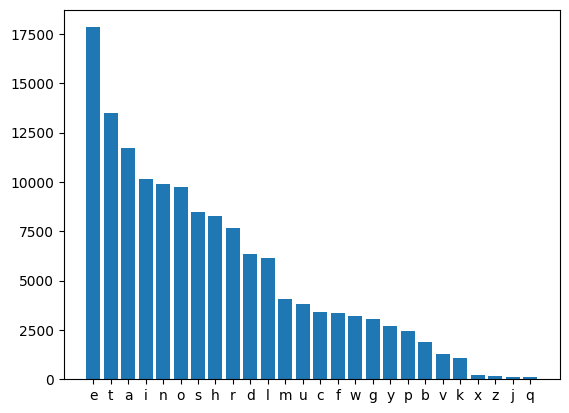

In [ ]:
import matplotlib.pyplot as plt

tokens, freqs = zip(*data.vocab.token_freqs)
tokens, freqs = list(tokens), list(freqs)
fig, ax = plt.subplots()
ax.bar(range(len(freqs)), freqs)
_ = ax.set_xticks(range(len(freqs)),labels=tokens)
#first_n_letters = 30
#ax.bar(range(first_n_letters), freqs[:first_n_letters])
#_ = ax.set_xticks(range(first_n_letters),labels=tokens[:first_n_letters], rotation=45)

In [ ]:
x, y = next(iter(dataloader)) #same as calling dataloader[0]
len(data.vocab)

27

In [ ]:
x.shape, y.shape #x:['a','n', 'c'... ] y:['n','c',...]

(torch.Size([1024, 32]), torch.Size([1024, 32]))

##Implementing a vanilla RNN
We define a vanilla RNN with three parameters:

- $W_{x}$: the weight matrix multiplying input $X_t$
- $W_{h}$: the weight matrix multiplying hidden state $H_{t-1}$
- $b$: the bias of the hidden state.

Altogether, the class applies the following recursion:

$f(X_t) = \phi(W_x X_t + W_h H_{t-1}+b) =  \phi\bigg(W_x X_t + W_h \phi(W_x X_{t-1} + W_h H_{t-2} +b )+b\bigg) = \dots $

Can you guess what will be $f(X_1)$?

In [ ]:
class RNN(nn.Module):

    """The RNN model implemented from scratch."""
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        # Weight matrix that multiplies input X_t
        self.W_x = nn.Parameter(
            torch.randn(num_inputs, num_hiddens) * sigma)

        # Weight matrix that multiplies output of hidden state H_(t-1)
        self.W_h = nn.Parameter(
            torch.randn(num_hiddens, num_hiddens) * sigma)

        #Bias of the hidden state
        self.b = nn.Parameter(torch.zeros(num_hiddens))

        #Activation function of the hidden layer
        self.activation_func = torch.tanh

    def forward(self, inputs, state=None):
      """Executes the RNN recurrent step.
      Inputs shape: (num_steps, batch_size, num_inputs)"""

      outputs = []

      if state is None:
          # Initial state with shape: (batch_size, num_hiddens)
          state = torch.zeros((inputs.shape[1], self.num_hiddens),
                            device=inputs.device)
      else:
        #Transformed input list in variable
          state, = state

      for X in inputs:
          state = self.activation_func(torch.matmul(X, self.W_x) + # X@self.W_x
                          torch.matmul(state, self.W_h) + self.b)
          outputs.append(state)  #outputs = [h_0, h_1, h_2, ...., h_t], state == outputs[-1]
      return outputs, state



##Implementing a classifier using RNNs (scratch)

We will use our RNN to predict the next $n$ tokens in a sequence of characters.
This problem is a classification problem because our input sequence is composed of integer tokens from a finite sets (alphanumeric characters). Our RNN will work as exemplified by the following picture:

rnn-train.svg

The goal is to predict the next token based on the current and past tokens by shifting the original sequence by one token for the target labels. For example, for the word "machine," the input is “machin” and the target is “achine.” During training, a softmax operation is applied at each time step on the output layer, and cross-entropy loss is calculated between the model output and target. The output at time step 3, for instance, is determined by the input sequence “m”, “a”, and “c”, and the loss depends on the probability of predicting the next character “h”. Each token is represented by a vector of vocab size, and the input at each time step is a matrix, adjusted for batch size.

In [ ]:
class RNNLMScratch(nn.Module):
    """The RNN-based language model implemented from scratch."""

    def __init__(self, rnn, vocab_size):
        super().__init__()

        self.rnn = rnn #our rnn from scratch
        self.vocab_size = vocab_size
        self.W_hq = nn.Parameter( #our output parameters
            torch.randn(
                self.rnn.num_hiddens, self.vocab_size) * self.rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(self.vocab_size))

    def one_hot(self, X):
        # Output shape: (num_steps, batch_size, vocab_size)
        return F.one_hot(X.T, self.vocab_size).type(torch.float32)

    def output_layer(self, rnn_outputs):
        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
        return torch.stack(outputs, 1)

    def forward(self, X, state=None):
        embs = self.one_hot(X) #one hot encoding of the indices of the tokens
        rnn_outputs, state = self.rnn(embs, state) #rnn applied to X, output is a list of hiddens
        assert rnn_outputs[-1] == state, "Something wrong in the RNN"
        return self.output_layer(rnn_outputs)

    def predict(self, prefix, num_preds, vocab, device=None):
      #prefix = 'there was a time' --> add num_preds more chars
        state, outputs = None, [vocab[prefix[0]]] # 't'
        for i in range(len(prefix) + num_preds - 1):
            X = torch.tensor([[outputs[-1]]], device=device)
            embs = self.one_hot(X)
            rnn_outputs, state = self.rnn(embs, state)
            if i < len(prefix) - 1:  # Warm-up period
                outputs.append(vocab[prefix[i + 1]])
            else:  # Predict num_preds steps
                Y = self.output_layer(rnn_outputs)
                Y = int(torch.argmax(Y, axis=2).squeeze())
                outputs.append(Y)
                #outputs.append(int(torch.reshape(torch.argmax(Y, axis=2), 1)))

        return ' '.join([vocab.idx_to_token[i] for i in outputs])

class TrainClassifier:
    def __init__(self, model, train_dataloader, val_dataloader=None, n_epochs=20, lr=0.001):
      self.model = model
      self.optimizer = optim.SGD(model.parameters(), lr=lr)
      self.train_dataloader = train_dataloader
      self.val_dataloader = val_dataloader
      self.n_epochs = n_epochs
      self.lr = lr

    def loss(self, Y_hat, Y, averaged=True):
        Y_hat = torch.reshape(Y_hat, (-1, Y_hat.shape[-1]))
        Y = torch.reshape(Y, (-1,))
        return F.cross_entropy(Y_hat, Y, reduction='mean' if averaged else 'none')

    def training_step(self, batch):
        l = self.loss(self.model(*batch[:-1]), batch[-1])
        self.train_loss.append(l)
        return l

    def validation_step(self, batch):
        l = self.loss(self.model(*batch[:-1]), batch[-1])
        self.val_loss.append(l)
        return l

    def fit(self):
      self.train_loss, self.val_loss = [], []

      pbar = tqdm(iterable=range(self.n_epochs*len(self.train_dataloader)))
      for epoch in range(self.n_epochs):
        self.model.train()
        avg_loss = 0
        for i, batch in enumerate(self.train_dataloader):
          self.optimizer.zero_grad()
          loss = self.training_step(batch) #loss = self.training_step(self.prepare_batch(batch))
          loss.backward()
          self.optimizer.step()
          avg_loss+=loss
          desc = f'Epoch:{epoch} - Avg loss:{(avg_loss/(i+1)):.5f}'
          pbar.set_description(desc)
          pbar.update(1)

        if self.val_dataloader is None:
          continue
          self.model.eval()
          for batch in self.val_dataloader:
              with torch.no_grad(): #makes sure that the resulting loss has no gradient
                  self.validation_step(batch)


In [ ]:
data = TimeMachine(file_name, batch_size=2**5, num_steps=16)
train_dataloader = data.get_dataloader(train=True)
rnn = RNN(num_inputs=len(data.vocab), num_hiddens=2**4)
model = RNNLMScratch(rnn, len(data.vocab))
#model.predict('there was a time', 10, data.vocab)


In [ ]:
x, y = next(iter(train_dataloader))


In [ ]:
trainer = TrainClassifier(model, train_dataloader, n_epochs=10)
trainer.fit()

Epoch:9 - Avg loss:3.21838: 100%|██████████| 3130/3130 [00:22<00:00, 139.87it/s]


In [ ]:
model.predict('there was a time', 10, data.vocab)

't h e r e <unk> w a s <unk> a <unk> t i m e e e e e e e e e e e'

#Lab Session 7
##Implementing a classifier using RNNs (torch)

In [ ]:
class RNNLMTorch(nn.Module):

  def __init__(self,
               vocab_size,  #cardinality of probability space (possible tokens to sample from)
               num_hiddens, #the dimensions of the hidden state of the RNN
               sigma=0.01):

    super().__init__()
    self.vocab_size = vocab_size
    self.num_hiddens = num_hiddens
    self.sigma = sigma
    self.rnn = nn.RNN(vocab_size, num_hiddens) #https://pytorch.org/docs/stable/generated/torch.nn.RNN.html
    self.linear = nn.Linear(num_hiddens, vocab_size)

  def one_hot(self, X):
      # Output shape: (num_steps, batch_size, vocab_size)
      return F.one_hot(X.T, self.vocab_size).type(torch.float32)

  def forward(self, X, state=None):
      embs = self.one_hot(X)
      rnn_outputs, _ = self.rnn(embs, state)
      return self.linear(rnn_outputs)

  def output_layer(self, rnn_outputs):
    return self.linear(rnn_outputs).swapaxes(0, 1)

  def predict(self, prefix, num_preds, vocab, device=None):
    #prefix = 'there was a time' --> add num_preds more chars
      state, outputs = None, [vocab[prefix[0]]] # 't'
      for i in range(len(prefix) + num_preds - 1):
          X = torch.tensor([[outputs[-1]]], device=device)
          embs = self.one_hot(X)
          rnn_outputs, state = self.rnn(embs, state)
          if i < len(prefix) - 1:  # Warm-up period
              outputs.append(vocab[prefix[i + 1]])
          else:  # Predict num_preds steps
              Y = self.output_layer(rnn_outputs)
              Y = int(torch.argmax(Y, axis=2).squeeze())
              outputs.append(Y)
              #outputs.append(int(torch.reshape(torch.argmax(Y, axis=2), 1)))

      return ' '.join([vocab.idx_to_token[i] for i in outputs])

In [ ]:
model = RNNLMTorch(vocab_size=len(data.vocab), num_hiddens=2**5)
trainer = TrainClassifier(model, train_dataloader, n_epochs=20)
trainer.fit()

Epoch:19 - Avg loss:2.95308: 100%|██████████| 6260/6260 [00:38<00:00, 160.68it/s]


In [ ]:
model.predict('there was a time', 10, data.vocab)

't h e r e <unk> w a s <unk> a <unk> t i m e e e e e e e e e e e'

##Implementing a classifier using a LSTM structure

We now implement a more sophisticated classifier using LSTM. In a LSTM network, each memory cell is equipped with an internal state $C$ and other gates that determine:

- the impact of input on the internal state $C$ (input gate $I$)
- the internal state should be flushed to (forget gate $F$)
- the impact of the internal state on the the output of the cell (output gate $O$).

lstm-0.svg



In [ ]:
class LSTM(nn.Module):

    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
                          init_weight(num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))

        self.W_xi, self.W_hi, self.b_i = triple()  # Input gate (will be activated by sigmoid)
        self.W_xf, self.W_hf, self.b_f = triple()  # Forget gate (will be activated by sigmoid)
        self.W_xo, self.W_ho, self.b_o = triple()  # Output gate (will be activated by sigmoid)
        self.W_xc, self.W_hc, self.b_c = triple()  # Input node ("memory", will be activated by tanh)

    def forward(self, inputs, H_C=None):

        if H_C is None:
            # Initial state with shape: (batch_size, num_hiddens)
            H = torch.zeros((inputs.shape[1], self.num_hiddens),
                          device=inputs.device)
            C = torch.zeros((inputs.shape[1], self.num_hiddens),
                          device=inputs.device)
        else:
            H, C = H_C

        outputs = []
        for X in inputs:
          #compute input and forget gates
            #sigmoid: output between [0,1]
            I = torch.sigmoid(torch.matmul(X, self.W_xi) +
                            torch.matmul(H, self.W_hi) + self.b_i)
            #sigmoid: output between [0,1]
            F = torch.sigmoid(torch.matmul(X, self.W_xf) +
                            torch.matmul(H, self.W_hf) + self.b_f)

            #sigmoid: output between [0,1]
            O = torch.sigmoid(torch.matmul(X, self.W_xo) +
                            torch.matmul(H, self.W_ho) + self.b_o)
            #tanh: output between [-1,1].

            #compute candidate state --> which will be [-1,1]
            C_tilde = torch.tanh(torch.matmul(X, self.W_xc) +
                              torch.matmul(H, self.W_hc) + self.b_c)

            #update internal state (or memory cell)
            C = F * C + I * C_tilde #C = C_tilde
            # use the updated memory to compute hidden state

            #output of the hidden cell is recurrent output O times activated internal state C
            H = O * torch.tanh(C) # if O is not there and F, I as well --> back to RNNs

            outputs.append(H)
        return outputs, (H, C)



In [ ]:
data = TimeMachine(file_name, batch_size=2**5, num_steps=16)
train_dataloader = data.get_dataloader(train=True)
gru = LSTM(num_inputs=len(data.vocab), num_hiddens=2**4)
model = RNNLMScratch(gru, len(data.vocab))
#model.predict('there was a time', 10, data.vocab)


Question: what happens if $W_{xc}$,$W_{hc}$ and $b_c$ are zero matrices?


In [ ]:
class LSTMTorch(RNNLMTorch):
  def __init__(self,
               vocab_size,  #cardinality of probability space (possible tokens to sample from)
               num_hiddens, #the dimensions of the hidden state of the RNN
               sigma=0.01):

    super().__init__(vocab_size, num_hiddens, sigma=sigma)
    #https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html
    self.rnn = LSTM(num_inputs=vocab_size,
                    num_hiddens=num_hiddens)

class GRUTorch(RNNLMTorch):
  def __init__(self,
               vocab_size,  #cardinality of probability space (possible tokens to sample from)
               num_hiddens, #the dimensions of the hidden state of the RNN
               sigma=0.01):

    super().__init__(vocab_size, num_hiddens, sigma=sigma)
    #https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html
    self.rnn = nn.GRU(input_size=vocab_size,
                       hidden_size=num_hiddens)

In [ ]:
model = LSTMTorch(len(data.vocab), num_hiddens=2**5)
trainer = TrainClassifier(model, train_dataloader, n_epochs=20)
trainer.fit()
#

  0%|          | 0/6260 [00:00<?, ?it/s]

TypeError: linear(): argument 'input' (position 1) must be Tensor, not list

In [ ]:
model.predict('there was a time', 10, data.vocab)


't h e r e <unk> w a s <unk> a <unk> t i m e e e e e e e e e e e'

## Implementing a classifier using a GRU structure

We now implement a GRU structure:

- **reset gate**: controls how much of the previous state we might still want to remember
- **update gate**: control how much of the new state is just a copy of the old one.

  gru-1.svg


Question: what is the value of the update of $C$ on the first loop (i.e. for $X_1$)?

In [ ]:
class GRUScratch(nn.Module):
  def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()

        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
                          init_weight(num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))
        self.W_xz, self.W_hz, self.b_z = triple()  # Update gate
        self.W_xr, self.W_hr, self.b_r = triple()  # Reset gate
        self.W_xh, self.W_hh, self.b_h = triple()  # Candidate hidden state

  def forward(self, inputs, H=None):
      if H is None:
          # Initial state with shape: (batch_size, num_hiddens)
          H = torch.zeros((inputs.shape[1], self.num_hiddens),
                        device=inputs.device)
      outputs = []
      for X in inputs:
          Z = torch.sigmoid(torch.matmul(X, self.W_xz) +
                          torch.matmul(H, self.W_hz) + self.b_z)
          R = torch.sigmoid(torch.matmul(X, self.W_xr) +
                          torch.matmul(H, self.W_hr) + self.b_r)
          H_tilde = torch.tanh(torch.matmul(X, self.W_xh) +
                            torch.matmul(R * H, self.W_hh) + self.b_h)
          H = Z * H + (1 - Z) * H_tilde
          outputs.append(H)
      return outputs, H

In [ ]:
x

tensor([[ 4,  9, 20,  ..., 19,  8,  1],
        [ 4, 19, 21,  ..., 14,  9, 14],
        [18,  9, 13,  ...,  1, 18,  5],
        ...,
        [15, 13,  2,  ..., 15, 18, 11],
        [ 1,  8,  5,  ..., 18,  5,  3],
        [18,  5, 23,  ..., 19, 25,  3]])

In [ ]:
x, y = next(iter(dataloader))

gru = GRUScratch(num_inputs=len(data.vocab), num_hiddens=12)

AttributeError: 'GRUScratch' object has no attribute 'num_hiddens'